## Movie Market Analysis
An analytical study of box office performance to provide strategic insights for guiding the development of a new movie studio. This a project from the Moringa Data Science Program.

## Project Objectives
1. Identify the top performing directors and top genres and their effect on the movie market.
2. Identify the top studios and the revenue they generate.
3. To determine which types of movies generate the highest Return on Investment (ROI), using budget and gross revenue data, in order to recommend profitable production strategies for the company new studio.
4. 

In [1]:
import itertools
import numpy as np
import pandas as pd 
from numbers import Number
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
warnings.filterwarnings('ignore')

import pickle

## Data Preparation

In [2]:
cd zippedData

C:\Users\PapaDay\Desktop\MovieMarket-analysis-phase 2\movie-market-analysis\zippedData


In [3]:
# Read CSV files compressed with gzip
bom_movie_gross = pd.read_csv('bom.movie_gross.csv.gz',encoding='latin1')

# Read TSV files compressed with gzip
rt_movie_info = pd.read_csv('rt.movie_info.tsv.gz', sep='\t',encoding='latin1')
rt_reviews = pd.read_csv('rt.reviews.tsv.gz', sep='\t',encoding='latin1')

# Read another CSV file compressed with gzip
tmdb_movies = pd.read_csv('tmdb.movies.csv.gz',encoding='latin1')

# Read the movie budgets compressed CSV
tn_movie_budgets = pd.read_csv('tn.movie_budgets.csv.gz',encoding='latin1')


In [4]:
bom_movie_gross

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [5]:
rt_movie_info

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,NaN,NaN,"Aug 18, 2006","Jan 2, 2007",$,"33,886,034",106 minutes,New Line Cinema
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,"Jul 23, 1993","Apr 17, 2001",NaN,NaN,88 minutes,Paramount Vantage
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,NaN,"Jan 1, 1962","May 11, 2004",NaN,NaN,111 minutes,NaN
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,"Apr 1, 1993","Jan 29, 2002",NaN,NaN,101 minutes,NaN


In [6]:
rt_reviews

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
...,...,...,...,...,...,...,...,...
54427,2000,The real charm of this trifle is the deadpan c...,NaN,fresh,Laura Sinagra,1,Village Voice,"September 24, 2002"
54428,2000,NaN,1/5,rotten,Michael Szymanski,0,Zap2it.com,"September 21, 2005"
54429,2000,NaN,2/5,rotten,Emanuel Levy,0,EmanuelLevy.Com,"July 17, 2005"
54430,2000,NaN,2.5/5,rotten,Christopher Null,0,Filmcritic.com,"September 7, 2003"


In [7]:
tmdb_movies

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
...,...,...,...,...,...,...,...,...,...,...
26512,26512,"[27, 18]",488143,en,Laboratory Conditions,0.600,2018-10-13,Laboratory Conditions,0.0,1
26513,26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.600,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,26514,"[14, 28, 12]",381231,en,The Last One,0.600,2018-10-01,The Last One,0.0,1
26515,26515,"[10751, 12, 28]",366854,en,Trailer Made,0.600,2018-06-22,Trailer Made,0.0,1


In [8]:
tn_movie_budgets

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


### Data Cleaning SQL Database

In [9]:
with zipfile.ZipFile('im.db.zip', 'r') as zip_ref:
    zip_ref.extractall('unzipped_db')
## Connect to the .db file
conn = sqlite3.connect('unzipped_db/im.db')
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

            name
0   movie_basics
1      directors
2      known_for
3     movie_akas
4  movie_ratings
5        persons
6     principals
7        writers


In [10]:
table_names = tables['name'].tolist()

# Step 2: Loop through tables
for table in table_names:
    print(f"\n=== Table: {table} ===\n")
    
    # Show columns
    columns = pd.read_sql_query(f"PRAGMA table_info({table});", conn)
    print("Columns:")
    print(columns[['name', 'type']])  # Just show column name and type for simplicity
    
    # Show first 5 rows
    sample_data = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn)
    print("\nSample rows:")
    print(sample_data)
    print("-" * 60)


=== Table: movie_basics ===

Columns:
              name     type
0         movie_id     TEXT
1    primary_title     TEXT
2   original_title     TEXT
3       start_year  INTEGER
4  runtime_minutes     REAL
5           genres     TEXT

Sample rows:
    movie_id                    primary_title              original_title  \
0  tt0063540                        Sunghursh                   Sunghursh   
1  tt0066787  One Day Before the Rainy Season             Ashad Ka Ek Din   
2  tt0069049       The Other Side of the Wind  The Other Side of the Wind   
3  tt0069204                  Sabse Bada Sukh             Sabse Bada Sukh   
4  tt0100275         The Wandering Soap Opera       La Telenovela Errante   

   start_year  runtime_minutes                genres  
0        2013            175.0    Action,Crime,Drama  
1        2019            114.0       Biography,Drama  
2        2018            122.0                 Drama  
3        2018              NaN          Comedy,Drama  
4        2017

In [11]:
movie_basics="""
SELECT *
FROM movie_basics
"""
movie_basics= pd.read_sql_query(movie_basics,conn)

In [12]:
movie_basics.isnull().sum()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [13]:
movie_basics.shape

(146144, 6)

In [14]:
movie_basics.duplicated().sum()

0

In [15]:
median_runtime = movie_basics["runtime_minutes"].median()
movie_basics["runtime_minutes"] = movie_basics["runtime_minutes"].fillna(median_runtime)

In [16]:
mode_genres = movie_basics["genres"].mode()[0]
movie_basics["genres"] = movie_basics["genres"].fillna(mode_genres)

In [17]:
movie_basics["original_title"] = movie_basics["original_title"].fillna("Unknown")

In [18]:
movie_basics.isnull().sum()

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

In [19]:
directors="""
SELECT *
FROM directors
"""
directors= pd.read_sql_query(directors,conn)

In [20]:
directors.isnull().sum()

movie_id     0
person_id    0
dtype: int64

In [21]:
movie_ratings="""
SELECT *
FROM movie_ratings
"""
movie_ratings= pd.read_sql_query(movie_ratings,conn)

In [22]:
movie_ratings.isnull().sum()

movie_id         0
averagerating    0
numvotes         0
dtype: int64

In [23]:
persons = pd.read_sql_query("SELECT * FROM persons", conn)

In [24]:
directors

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502
...,...,...
291169,tt8999974,nm10122357
291170,tt9001390,nm6711477
291171,tt9001494,nm10123242
291172,tt9001494,nm10123248


In [25]:
movie_basics

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,87.0,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,87.0,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,87.0,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,Documentary


## Exploratory Data Analysis

On this section we will be merging tables and relating them to our objectives.
Let's start with directors and ratings of the movies they produce to see top performing directors

In [26]:
# Merge movie_basics with movie_ratings
movies = pd.merge(movie_basics, movie_ratings, on="movie_id", how="inner")

# Merge with directors
movies_directed = pd.merge(movies, directors, on="movie_id", how="inner")

# Merge with persons to get director names
full_data = pd.merge(movies_directed, persons, on="person_id", how="inner")

full_data = full_data[[
    'movie_id', 'primary_title', 'start_year', 'runtime_minutes', 'genres',
    'averagerating', 'numvotes', 'person_id', 'primary_name'
]]

full_data.rename(columns={'primary_name': 'director_name'}, inplace=True)



In [27]:
full_data

,movie_id,primary_title,start_year,runtime_minutes,genres,averagerating,numvotes,person_id,director_name
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77,nm0712540,Harnam Singh Rawail
1,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77,nm0712540,Harnam Singh Rawail
2,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77,nm0712540,Harnam Singh Rawail
3,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77,nm0712540,Harnam Singh Rawail
4,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama",7.2,43,nm0002411,Mani Kaul
...,...,...,...,...,...,...,...,...,...
181382,tt9911774,Padmavyuhathile Abhimanyu,2019,130.0,Drama,8.4,365,nm10536451,Vineesh Aaradya
181383,tt9913056,Swarm Season,2019,86.0,Documentary,6.2,5,nm1502645,Sarah Christman
181384,tt9914942,La vida sense la Sara Amat,2019,87.0,Documentary,6.6,5,nm1716653,Laura Jou
181385,tt9914942,La vida sense la Sara Amat,2019,87.0,Documentary,6.6,5,nm1716653,Laura Jou


In [28]:
duplicate_count = full_data.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 95357


In [29]:
full_data = full_data.drop_duplicates(subset=['movie_id', 'person_id'])

In [30]:
print(f"Shape after deduplication: {full_data.shape}")

Shape after deduplication: (86030, 9)


Lets get started on some Exploratory Data Analysis.
### Step 1: Filter Directors with Enough Movies and Votes
We'll filter to include only:
Directors with at least 3 movies in the dataset and movies with a minimum number of votes (numvotes >= 100) to avoid fringe cases.

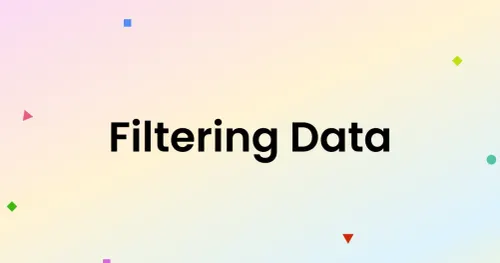

In [31]:
filtered_data = full_data[full_data['numvotes'] >= 100]

director_movie_counts = filtered_data.groupby('director_name')['movie_id'].count()

valid_directors = director_movie_counts[director_movie_counts >= 3].index

filtered_data = filtered_data[filtered_data['director_name'].isin(valid_directors)]


### Step 2: Top Directors by Average Rating
Now, let's find the top performing director. By filtering above we can have better insights based on performing directors

In [32]:
top_directors = (
    filtered_data.groupby('director_name')
    .agg(avg_rating=('averagerating', 'mean'),
         num_movies=('movie_id', 'count'),
         total_votes=('numvotes', 'sum'))
    .sort_values(by='avg_rating', ascending=False)
    .head(10)
)

print(top_directors)

                   avg_rating  num_movies  total_votes
director_name                                         
Zheng Zhou           8.825000           4          441
Steve Ravic          8.750000           4         4994
Quentin Tarantino    8.675000           4      1655377
Tim Van Someren      8.575000           4         3412
Mike Stoklasa        8.500000           3          974
Christopher Nolan    8.425000           4      4994749
Jia Tian             8.400000           3          326
Vetrimaaran          8.400000           3        14699
Tauquir Ahmed        8.400000           3         3541
Rishab Shetty        8.366667           3         4908


That can show how the directors perform but might not be accurate to show who truly deserves the top slot based on consistency when it comes to producing more performing movies.

### Director Ranking: Hybrid Methodology

To identify the top-performing directors more reliably, we use a **hybrid ranking approach** that combines two key components:

1. **Weighted Average Rating**  
   This adjusts the director's average rating based on how many votes their films received, using a formula inspired by IMDb:
   
   \[
   \text{Weighted Rating} = \frac{v}{v + m} \cdot R + \frac{m}{v + m} \cdot C
   \]
   
   Where:
   - \( R \) = director's average movie rating
   - \( v \) = total number of votes for all movies by that director(Over 150000)
   - \( m \) = minimum vote threshold (over 200000 votes)
   - \( C \) = overall average rating across all movies

   This helps discount the effect of high ratings from low-visibility films with few votes.

2. **Rating Consistency**  
   We reward directors whose movies maintain a consistent quality. Consistency is defined as the inverse of the standard deviation of their movie ratings:
   
   \[
   \text{Consistency} = \frac{1}{\text{Standard Deviation of Ratings} + 0.01}
   \]
   
   This favors directors who deliver reliably well-received films.

3. **Hybrid Score**  
   The final score is a weighted combination:
   
   \[
   \text{Hybrid Score} = 0.7 \cdot \text{Weighted Rating} + 0.3 \cdot \text{Consistency}
   \]

   This gives us a balanced view of both **overall rating strength** and **reliability**.

The top-ranked directors based on this methodology are shown below.


In [37]:
C = filtered_data['averagerating'].mean()
m = 200000  #This favors highly voted directors

director_stats = (
    filtered_data.groupby('director_name')
    .agg(avg_rating=('averagerating', 'mean'),
         total_votes=('numvotes', 'sum'),
         num_movies=('movie_id', 'count'),
         rating_std=('averagerating', 'std'))
    .fillna(0)
)
director_stats = director_stats[
    (director_stats['num_movies'] >= 3) &
    (director_stats['total_votes'] >= 150000) &
    (director_stats['avg_rating'] >= 7.0)
]
# Weighted rating
director_stats['weighted_rating'] = (
    (director_stats['total_votes'] / (director_stats['total_votes'] + m)) * director_stats['avg_rating'] +
    (m / (director_stats['total_votes'] + m)) * C
)

# Hybrid: weighted_rating, add bonus for consistency
director_stats['consistency'] = 1 / (director_stats['rating_std'] + 0.01)
director_stats['score'] = (
    director_stats['weighted_rating'] * 0.85 +
    director_stats['consistency'] * 0.15
)

# Final sorted result
top_directors = director_stats.sort_values('score', ascending=False).head(10).reset_index()


In [38]:
top_directors[['director_name', 'avg_rating', 'total_votes', 'num_movies', 'weighted_rating', 'consistency', 'score']]\
    .style.format({
        'avg_rating': '{:.2f}',
        'weighted_rating': '{:.2f}',
        'consistency': '{:.2f}',
        'score': '{:.2f}',
        'total_votes': '{:,}'
    })\
    .set_caption("Top 10 Directors Ranked by Hybrid Score")


,director_name,avg_rating,total_votes,num_movies,weighted_rating,consistency,score
0,Christopher Nolan,8.43,"4,994,749",4,8.33,2.52,7.46
1,Wes Anderson,7.93,"1,033,599",3,7.61,6.14,7.39
2,Quentin Tarantino,8.68,"1,655,377",4,8.38,1.24,7.31
3,Derek Cianfrance,7.30,"443,101",3,6.88,9.09,7.21
4,David Fincher,7.87,"1,717,750",3,7.67,4.58,7.20
5,Anthony Russo,8.23,"2,361,820",4,8.05,1.94,7.13
6,Joe Russo,8.23,"2,361,820",4,8.05,1.94,7.13
7,Justin Lin,7.17,"886,483",3,6.94,7.97,7.10
8,Ryan Coogler,7.47,"809,006",3,7.17,6.14,7.01
9,Taika Waititi,7.75,"713,498",4,7.36,4.96,7.00


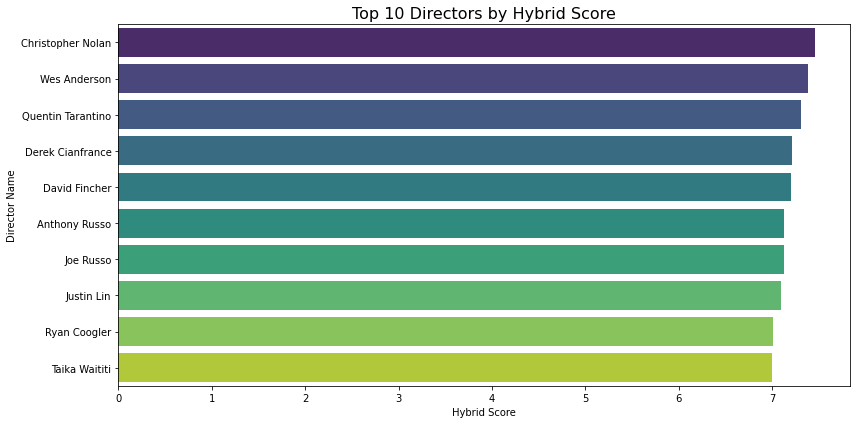

In [39]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x='score',
    y='director_name',
    data=top_directors,
    palette='viridis'
)

plt.title('Top 10 Directors by Hybrid Score', fontsize=16)
plt.xlabel('Hybrid Score')
plt.ylabel('Director Name')
plt.tight_layout()
plt.show()

In [36]:
top_directors.shape

(10, 8)